# Adversarial Patch — ImageNet Playground
End-to-end notebook for generating and evaluating model-specific adversarial patches on ImageNet validation images.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image

from model_factory import get_art_classifier
from patch_utility import generate_adversarial_patch, apply_adversarial_patch, save_patched_image
from eval_utility import load_imagenet_batch, evaluate_patch, evaluate_all_models

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

## 1. Load a batch of ImageNet validation images

In [ ]:
# 1050 has 2-4GB VRAM — keep batch small to avoid OOM
x_batch, labels = load_imagenet_batch(n_images=8, shard=0)
print(f"Loaded {len(x_batch)} images, shape: {x_batch.shape}")
print(f"Label range: {labels.min()} – {labels.max()}")

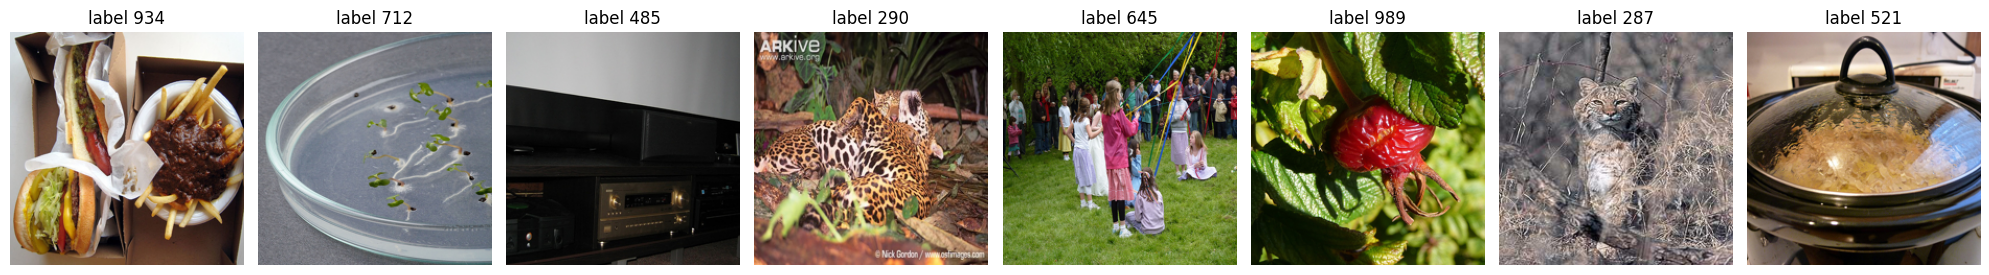

In [3]:
# Preview first 8 images
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i, ax in enumerate(axes):
    ax.imshow(np.transpose(x_batch[i], (1, 2, 0)))
    ax.set_title(f"label {labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Load a model and generate the adversarial patch

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "resnet18"  # the model this patch targets

print(f"Using device: {DEVICE}")
classifier = get_art_classifier(MODEL_NAME, device=DEVICE)

In [5]:
# Generate the optimized patch — this is the expensive step
patch, attack = generate_adversarial_patch(
    classifier=classifier,
    x_batch=x_batch,
    y_batch=labels,
    max_iter=500,
    learning_rate=5.0,
)
print(f"Patch shape: {patch.shape}")

Adversarial Patch PyTorch:   0%|          | 0/500 [00:00<?, ?it/s]

Adversarial Patch PyTorch: 100%|██████████| 500/500 [25:07<00:00,  3.01s/it]

Patch shape: (3, 56, 56)


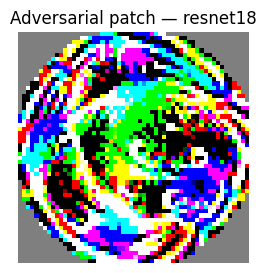

In [6]:
# Visualize the patch
patch_img = np.transpose(np.clip(patch, 0, 1), (1, 2, 0))
plt.figure(figsize=(3, 3))
plt.imshow(patch_img)
plt.title(f"Adversarial patch — {MODEL_NAME}")
plt.axis('off')
plt.show()

## 3. Apply and evaluate — location independence test

ValueError: a must be greater than 0 unless no samples are taken

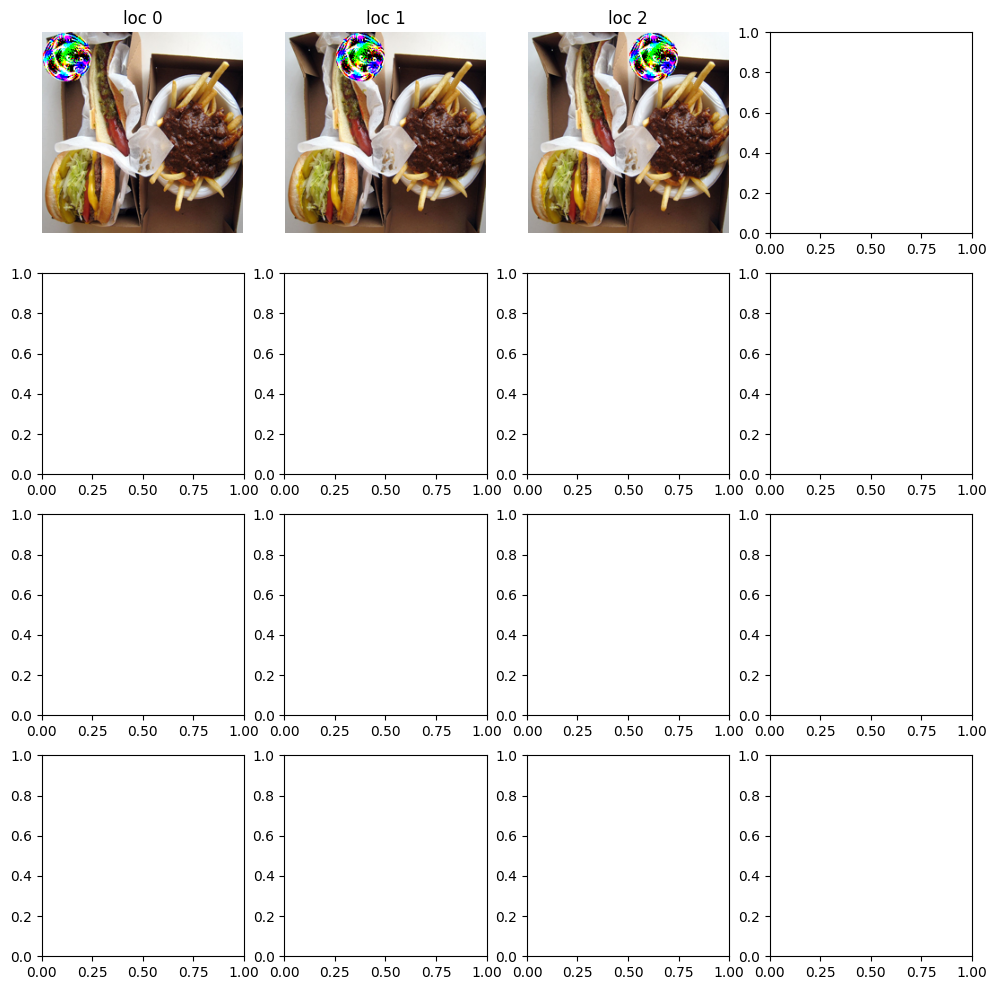

In [8]:
# Test all 16 grid locations on the same image
sample = x_batch[:1]  # single image
sample_label = labels[:1]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for loc in range(16):
    ax = axes[loc // 4][loc % 4]
    x_p = apply_adversarial_patch(patch, attack, sample, patch_location=loc)
    ax.imshow(np.transpose(x_p[0], (1, 2, 0)))
    ax.set_title(f"loc {loc}")
    ax.axis('off')
plt.suptitle("Patch at all 16 grid locations", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate patch effectiveness per location
print(f"{'Location':>10} | {'Clean prob':>10} | {'Patched prob':>12} | {'Drop':>8}")
print("-" * 50)
for loc in range(16):
    x_p = apply_adversarial_patch(patch, attack, sample, patch_location=loc)
    metrics = evaluate_patch(classifier, sample, x_p, sample_label)
    drop = metrics['clean_prob_mean'] - metrics['patched_prob_mean']
    print(f"{loc:>10} | {metrics['clean_prob_mean']:>10.2%} | {metrics['patched_prob_mean']:>12.2%} | {drop:>8.2%}")

## 4. Evaluate patch across all 6 models (transferability)

In [ ]:
# Load a fresh held-out batch for unbiased evaluation
x_eval, labels_eval = load_imagenet_batch(n_images=32, shard=1)

results = evaluate_all_models(patch, attack, x_eval, labels_eval, device=DEVICE)

print(f"\n{'Model':>10} | {'Clean Acc':>10} | {'Patched Acc':>11} | {'Clean P(y)':>10} | {'Patched P(y)':>12}")
print("-" * 65)
for model_name, m in results.items():
    if m:
        print(f"{model_name:>10} | {m['clean_acc']:>10.2%} | {m['patched_acc']:>11.2%} | {m['clean_prob_mean']:>10.2%} | {m['patched_prob_mean']:>12.2%}")

## 5. Save a patched example

In [ ]:
x_p = apply_adversarial_patch(patch, attack, x_batch[:1], patch_location=0)
out_path = save_patched_image(x_p, "data/patched", f"patch_{MODEL_NAME}_loc0.png")
print(f"Saved to {out_path}")
display(Image.open(out_path))